### Configuração do LDA

In [46]:
import pandas as pd
import gensim
from gensim import corpora
from gensim.models import LdaModel
import nltk
import re

In [47]:
# Carrega o dataset
df_novo = pd.read_csv('database-lemmetizado.csv.zip', compression='zip')

In [48]:
documents = df_novo['tokens'].dropna().astype(str).tolist()

In [49]:
# Usar esse caso o dataset esteja pre-processado
def tokenize_text(text):
    """
    Função para tokenizar o texto.
    """

    # Converte para minúsculas e separa em palavras
    tokens = text.lower().split()

    return tokens

# Tokeniza os textos
processed_docs = [tokenize_text(doc) for doc in documents]

# Cria dicionário e corpus
# O dicionário mapeia cada palavra a um ID único.
dictionary = corpora.Dictionary(processed_docs)

# O corpus é a representação Bag-of-Words de cada documento.
# Para cada documento, ele contém uma lista de tuplas (ID_da_palavra, frequência).
corpus = [dictionary.doc2bow(doc) for doc in processed_docs]

In [50]:
print(f"Número de documentos: {len(corpus)}")
print(f"Tamanho do dicionário: {len(dictionary)}")
print(f"Exemplo de documento (Bag-of-Words): {corpus[0]}")
print(f"processed_docs[0]: {processed_docs[0]}")

Número de documentos: 25240
Tamanho do dicionário: 48753
Exemplo de documento (Bag-of-Words): [(0, 6), (1, 1), (2, 3), (3, 1), (4, 1), (5, 8), (6, 2), (7, 1), (8, 7), (9, 1), (10, 3), (11, 4), (12, 5), (13, 1), (14, 1), (15, 1), (16, 2), (17, 3), (18, 1), (19, 1), (20, 1), (21, 1), (22, 1), (23, 1), (24, 1), (25, 1), (26, 1), (27, 5), (28, 2), (29, 1), (30, 4), (31, 1), (32, 1), (33, 1), (34, 1), (35, 1), (36, 2), (37, 6), (38, 1), (39, 1), (40, 1)]
processed_docs[0]: ["['dispositivo',", "'sedimentação',", "'dispositivo',", "'sedimentação',", "'invenção',", "'referir',", "'dispositivo',", "'sedimentação',", "'material',", "'contido',", "'líquido',", "'particular',", "'precipitação',", "'pluvial',", "'elemento',", "'sedimentação',", "'inserir',", "'uso',", "'elemento',", "'poço',", "'elemento',", "'sedimentação',", "'apresentar',", "'câmara',", "'entrada',", "'delimitado',", "'parede',", "'lateral',", "'câmara',", "'entrada',", "'equipar',", "'abertura',", "'entrada',", "'lateral',", "'

### Treinamento do modelo

In [51]:
# Treina o modelo LDA
lda_model = LdaModel(
    corpus=corpus,
    id2word=dictionary,
    num_topics=10, # Número de tópicos
    random_state=42,
    passes=20,
    alpha='auto', # (Document-Topic Density): Controla a mistura de tópicos por documento
    eta='auto' # (Topic-Word Density): Controla a mistura de palavras por tópico
)

In [52]:
# Exibe os tópicos encontrados
for idx, topic in lda_model.print_topics(-1):
    print(f'Tópico {idx}: {topic}')

Tópico 0: 0.035*"'material'," + 0.019*"'camada'," + 0.019*"'revestimento'," + 0.017*"'processo'," + 0.013*"'invenção'," + 0.013*"'método'," + 0.012*"'fibra'," + 0.011*"'compreender'," + 0.008*"'fabricação'," + 0.008*"'superfície',"
Tópico 1: 0.053*"'água'," + 0.015*"'ar'," + 0.015*"'energia'," + 0.011*"'piscina'," + 0.010*"'equipamento'," + 0.009*"'dispositivo'," + 0.008*"'tanque'," + 0.008*"'elétrico'," + 0.007*"'reservatório'," + 0.006*"'flutuante',"
Tópico 2: 0.058*"'construção'," + 0.042*"'concreto'," + 0.033*"'bloco'," + 0.020*"'estrutural'," + 0.020*"'parede'," + 0.019*"'civil'," + 0.019*"'estrutura'," + 0.018*"'viga'," + 0.016*"'laje'," + 0.011*"'elemento',"
Tópico 3: 0.029*"'elemento'," + 0.022*"'suporte'," + 0.018*"'extremidade'," + 0.017*"'compreender'," + 0.015*"'membro'," + 0.015*"'dispositivo'," + 0.015*"'trilho'," + 0.014*"'porção'," + 0.014*"'estrutura'," + 0.013*"'incluir',"
Tópico 4: 0.042*"'painel'," + 0.026*"'parede'," + 0.023*"'placa'," + 0.019*"'elemento'," + 0.019

### Gráfico de Tópicos

In [53]:
import matplotlib.pyplot as plt

# Extrai os tópicos e palavras
topics = lda_model.show_topics(num_topics=-1, num_words=10, formatted=False)

fig, axes = plt.subplots(len(topics), 1, figsize=(10, 2 * len(topics)), constrained_layout=True)

for i, (topic_idx, terms) in enumerate(topics):
    words = [w for w, p in terms]
    probs = [p for w, p in terms]
    axes[i].barh(words, probs)
    axes[i].set_title(f'Tópico {topic_idx}')
    axes[i].invert_yaxis()
    axes[i].set_xlabel('% de importância')
    axes[i].set_xlim(0, max(probs)*1.1)

plt.savefig('lda_topicos.png', dpi=300)
plt.close()

print("Gráfico salvo como 'lda_topicos.png'")

Gráfico salvo como 'lda_topicos.png'


### Data Frame com os tópicos de cada patente

In [54]:
# 1. Definir os nomes dos tópicos conforme sua interpretação.
topic_names = {
    0: 'Processos de Fabricação e Materiais Compósitos',
    1: 'Equipamentos para Fluidos (Água/Ar) e Energia',
    2: 'Construção Civil Estrutural (Concreto e Vigas)',
    3: 'Componentes de Montagem e Suporte (Trilhos)',
    4: 'Painéis, Placas e Revestimentos (Pisos/Paredes)',
    5: 'Linguagem Genérica de Patentes',
    6: 'Disposições Construtivas e Fixação',
    7: 'Portas, Janelas e Fechaduras',
    8: 'Máquinas, Motores e Sistemas de Controle',
    9: 'Sistemas Hidráulicos e Sanitários (Descargas/Válvulas)'
}

In [55]:
import pandas as pd

# 2. Preparar uma lista para armazenar os dados de cada patente.
corpus_topics_data = []

# 3. Iterar sobre cada documento no seu corpus.
for i, doc_bow in enumerate(corpus):
    # Pega a distribuição de tópicos para o documento atual.
    doc_topics = lda_model.get_document_topics(doc_bow, minimum_probability=0.0)
    
    # Cria um dicionário com a probabilidade de cada tópico para este documento.
    # Inicializamos com 0 para todos os tópicos.
    topic_probabilities = {topic_names[j]: 0.0 for j in range(lda_model.num_topics)}
    
    # Preenche com as probabilidades reais do modelo.
    for topic_num, prop_topic in doc_topics:
        topic_probabilities[topic_names[topic_num]] = prop_topic
        
    # Adiciona o ID e titulo da patente à informação.
    # Assumindo que 'lista_patentes' tem os títulos ou IDs.
    topic_probabilities['ID'] = df_novo["docdb_id"].iloc[i]
    topic_probabilities['Nome'] = df_novo["invention_title_text"].iloc[i]
    
    # Adiciona o dicionário completo à nossa lista de dados.
    corpus_topics_data.append(topic_probabilities)

# 4. Criar o DataFrame do pandas.
df_topics = pd.DataFrame(corpus_topics_data)

# 5. Criar uma coluna para identificar o tópico dominante de cada patente.
# O método idxmax() encontra o nome da coluna (nosso nome de tópico) com o maior valor na linha.
df_topics['Tópico Principal'] = df_topics[list(topic_names.values())].idxmax(axis=1)

# 6. Ordena os campos para melhor visualização.
df_topics = df_topics[['ID', 'Nome', 'Tópico Principal'] + list(topic_names.values())]

In [57]:
df_topics

,ID,Nome,Tópico Principal,Processos de Fabricação e Materiais Compósitos,Equipamentos para Fluidos (Água/Ar) e Energia,Construção Civil Estrutural (Concreto e Vigas),Componentes de Montagem e Suporte (Trilhos),"Painéis, Placas e Revestimentos (Pisos/Paredes)",Linguagem Genérica de Patentes,Disposições Construtivas e Fixação,"Portas, Janelas e Fechaduras","Máquinas, Motores e Sistemas de Controle",Sistemas Hidráulicos e Sanitários (Descargas/Válvulas)
0,558602417,Dispositivo de sedimentação,Sistemas Hidráulicos e Sanitários (Descargas/V...,0.001903,0.076258,0.001972,0.002535,0.337098,0.003578,0.004589,0.002768,0.001630,0.567669
1,383346957,canal com turbinas acoplados nos geradores par...,Equipamentos para Fluidos (Água/Ar) e Energia,0.003864,0.658729,0.003986,0.005242,0.005407,0.007840,0.106382,0.005825,0.077566,0.125159
2,383323608,"Mola tensionadora de fio de arame farpado, de ...",Disposições Construtivas e Fixação,0.259222,0.001394,0.167533,0.112275,0.002509,0.040688,0.317963,0.095575,0.001545,0.001297
3,569902860,Sistema contentor de lubrificantes para automa...,"Portas, Janelas e Fechaduras",0.312978,0.002352,0.003167,0.004043,0.041105,0.072507,0.007062,0.424943,0.098834,0.033009
4,586397134,MÉTODO DE GERAÇÃO DE ENERGIA ELÉTRICA E SISTEM...,Equipamentos para Fluidos (Água/Ar) e Energia,0.001069,0.451837,0.001116,0.038456,0.017030,0.002105,0.046669,0.001580,0.114397,0.325741
...,...,...,...,...,...,...,...,...,...,...,...,...,...
25235,544402970,disposição de um elemento de andaime vertical ...,Componentes de Montagem e Suporte (Trilhos),0.016153,0.000573,0.007743,0.818313,0.031441,0.001456,0.047519,0.054373,0.000635,0.021795
25236,512309356,disposição aplicada em caixa de gordura,Sistemas Hidráulicos e Sanitários (Descargas/V...,0.001964,0.001524,0.002039,0.002656,0.070611,0.003989,0.301949,0.002835,0.001685,0.610750
25237,583562151,DISPOSIÇÃO CONSTRUTIVA APLICADA EM SAPATO COM ...,Linguagem Genérica de Patentes,0.251046,0.001627,0.081875,0.002791,0.051161,0.335475,0.190956,0.018964,0.035911,0.030195
25238,383307122,Blindagem anti-furo para cofres e caixas forte...,Equipamentos para Fluidos (Água/Ar) e Energia,0.122945,0.252620,0.081918,0.011157,0.116139,0.156667,0.046179,0.127987,0.009433,0.074954


## Vizualizar uma patente especifica

C:\Users\pedro\AppData\Local\Temp\ipykernel_16776\3269435232.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')


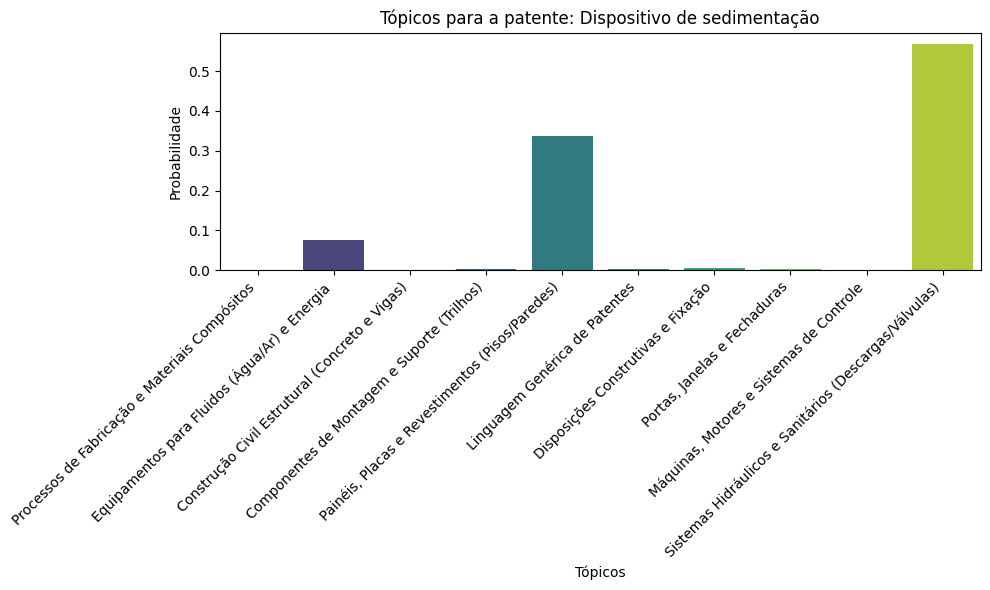

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

indice_patente = 0
patente_especifica = df_topics.iloc[indice_patente]

# Pega apenas as colunas que representam as probabilidades dos tópicos
probabilidades_topicos = patente_especifica[list(topic_names.values())]

# Cria o gráfico
plt.figure(figsize=(10, 6)) # Define o tamanho da figura
sns.barplot(x=probabilidades_topicos.index, y=probabilidades_topicos.values, palette='viridis')

# Adiciona títulos e rótulos
plt.title(f'Tópicos para a patente: {patente_especifica["Nome"]}')
plt.xlabel('Tópicos')
plt.ylabel('Probabilidade')
plt.xticks(rotation=45, ha='right') # Rotaciona os nomes dos tópicos para não sobrepor
plt.tight_layout() # Ajusta o layout para caber tudo

# Mostra o gráfico
plt.show()